
# 03_02 Group data with clustering algorithms

In this notebook, you will use K-Means clustering to find structure in the classic Iris dataset.

![Iris Image](https://www.sakurai.dev.br/assets/images/posts/2018-10-17-classificacao-iris-01.png)


## Load the Iris dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

path = './data/iris.csv'
df = pd.read_csv(path)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


sklearn.metrics.silhouette_score gives you a single number that measures how well your data has been clustered. It’s based on the silhouette coefficient of each point, which compares:

a(i): how close a point is to other points in its own cluster (intra-cluster distance), and

b(i): how far it is from points in the nearest other cluster (nearest-cluster distance).

Range: 

Close to 1: Samples are well-matched to their own cluster and far from other clusters (good separation).

Around 0: Clusters overlap or boundaries are fuzzy.

Negative: Samples may be assigned to the wrong cluster.

In [2]:
# df.to_csv('./data/iris.csv', index=False)

## Prepare numeric features for clustering

In [3]:
X = df.drop(['species'], axis=1)
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Scale the features

In [4]:
scaler = sklearn.preprocessing.StandardScaler() #This scaler standardize features: for each column/feature it subtract the mean and divide by the standard deviation.
X_scaled = scaler.fit_transform(X)
'''
fit: computes the mean and standard deviation from X (column by column).
transform: uses those statistics to transform X into standardized values.
Combined, fit_transform returns the scaled version of X as X_scaled.
'''
X_scaled[:5] #Shows the first 5 rows of the scaled array (or DataFrame-like result).


array([[-0.90068117,  1.03205722, -1.3412724 , -1.31297673],
       [-1.14301691, -0.1249576 , -1.3412724 , -1.31297673],
       [-1.38535265,  0.33784833, -1.39813811, -1.31297673],
       [-1.50652052,  0.10644536, -1.2844067 , -1.31297673],
       [-1.02184904,  1.26346019, -1.3412724 , -1.31297673]])

## Identify number of clusters (k)

**Elbow**: “Inertia drops rapidly until k ≈ X, after which gains are modest.”  

When you try different numbers of clusters in k‑means, the amount of clustering error (called inertia) decreases quickly at first as you add more clusters. But after you reach about k = X, adding additional clusters doesn’t improve the clustering very much. The improvement becomes small and slow.
Think of it like this:

Before k ≈ X → each extra cluster helps the model a lot.
After k ≈ X → each extra cluster helps only a little.

This point where the improvement slows down is the “elbow,” and it suggests a good choice for the number of clusters.

High inertia → points are far from their centroids → bad clustering (loose clusters)

Low inertia → points are close to their centroids → good clustering (tight clusters)

**Diminishing returns**: “The first relative improvement below 15% occurs at k = X, so we select k = X as the knee.”  

As you increase the number of clusters, the model keeps improving, but at some point the improvement becomes small. The first time the improvement in performance drops to less than 15%, it happens when k = X.
This tells us that adding more clusters after k = X won’t help much, so k = X is chosen as the “knee” point.
Even simpler version

When k is small → adding clusters helps a lot.
When k reaches X → improvement falls below 15%.
After that → adding more clusters barely helps.
So k = X is a good stopping point.

**Silhouette**: “Silhouette peaks at k = Y with a score of S. Since Y [matches / differs from] X by [amount],  
we [keep k = X for parsimony / choose k = Y for better separation].”

The best silhouette score happens at k = Y.
We check how different Y is from X.
If they’re similar → choose X to keep things simple.
If silhouette shows Y is clearly better → choose Y for better clustering.

C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

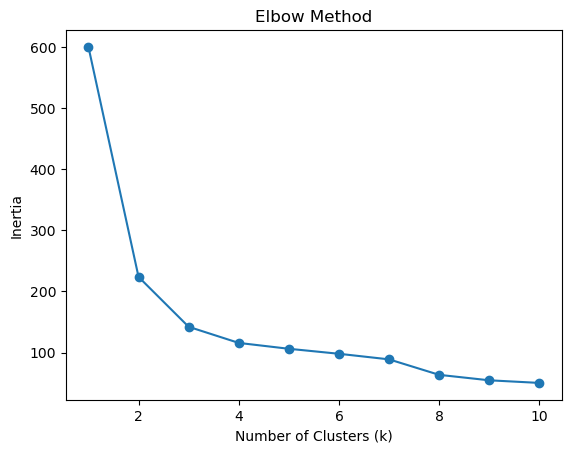

Absolute drops (k->k+1): [376.3  81.6  26.4   9.6   8.2   9.1  25.3   8.9   4.3]
Relative drops (k->k+1): [62.7 36.5 18.6  8.3  7.7  9.3 28.5 14.1  7.9] %
Suggested k by knee heuristic: k = 4


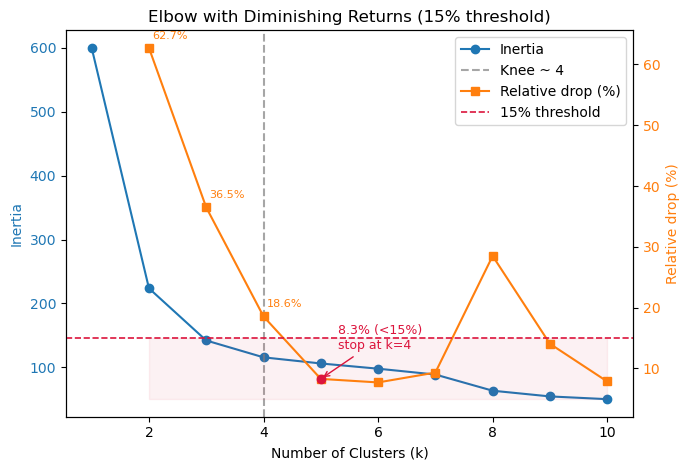

In [5]:
# --- 0) OPTIONAL: scale features if not already scaled ---
# from sklearn.preprocessing import StandardScaler
# X = StandardScaler().fit_transform(X)

# --- 1) Compute inertia over k=1..10 (elbow) ---
ks = np.arange(1, 11)
inertias = []
for k in ks:
    km = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=1)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
inertias = np.array(inertias)

plt.figure()
plt.plot(ks, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# --- 2) Knee (diminishing returns) heuristic ---
abs_drop = np.diff(inertias) * -1              # improvement from k -> k+1
rel_drop = abs_drop / inertias[:-1]            # relative improvement
threshold = 0.15                               # 15% is a good starting point
candidates = np.where(rel_drop < threshold)[0] # indices for transitions (k -> k+1)

if len(candidates) > 0:
    k_knee = candidates[0] + 1                 # convert diff index to k
else:
    k_knee = int(np.argmin(np.gradient(np.gradient(inertias))) + 1)  # fallback: curvature heuristic

print("Absolute drops (k->k+1):", np.round(abs_drop, 1))
print("Relative drops (k->k+1):", np.round(100*rel_drop, 1), "%")
print(f"Suggested k by knee heuristic: k = {k_knee}")

# --- Annotated plot: Elbow with diminishing returns + 15% threshold ---
fig, ax1 = plt.subplots(figsize=(7, 4.8))

# Left axis: inertia
ax1.plot(ks, inertias, marker='o', color='tab:blue', label='Inertia')
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_title("Elbow with Diminishing Returns (15% threshold)")
ax1.axvline(x=k_knee, color='gray', linestyle='--', alpha=0.7, label=f'Knee ~ {k_knee}')

# Right axis: relative drop (%)
ax2 = ax1.twinx()
ax2.plot(ks[1:], rel_drop*100, marker='s', color='tab:orange', label='Relative drop (%)')
ax2.set_ylabel("Relative drop (%)", color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# --- Add 15% threshold line on the relative-drop axis ---
ax2.axhline(y=threshold*100, color='crimson', linestyle='--', linewidth=1.2, label='15% threshold')

# Optional: lightly shade the "below-threshold" region
ymin, ymax = ax2.get_ylim()
ax2.fill_between([ks[1], ks[-1]], threshold*100, ymin, color='crimson', alpha=0.06)

# Emphasize the first below-threshold point (if any)
if len(candidates) > 0:
    idx = candidates[0]            # index in rel_drop for transition k -> k+1
    k_from = ks[idx]               # this is the k on the left of the transition
    ax2.scatter([k_from+1], [rel_drop[idx]*100], color='crimson', zorder=5)
    ax2.annotate(
        f"{rel_drop[idx]*100:.1f}% (<15%)\nstop at k={k_from}",
        xy=(k_from+1, rel_drop[idx]*100),
        xytext=(k_from+1.3, rel_drop[idx]*100 + (ymax - ymin)*0.08),
        arrowprops=dict(arrowstyle="->", color='crimson', lw=1.0),
        fontsize=9, color='crimson'
    )

# Optional: show value labels for the first few relative drops for transparency
for i, (k_from, rd) in enumerate(zip(ks[:-1], rel_drop)):
    if i < 3:  # label the first 3 transitions: 1->2, 2->3, 3->4
        ax2.annotate(f"{rd*100:.1f}%",
                     xy=(k_from+1, rd*100),
                     xytext=(k_from+1+0.05, rd*100+1.5),
                     fontsize=8, color='tab:orange')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='best')

plt.tight_layout()
plt.show()

## Fit a K-Means clustering model

In [12]:
kmeans = KMeans(n_clusters=4, random_state=1, n_init='auto')
kmeans.fit(X_scaled)

cluster_labels = kmeans.labels_


C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Compare clusters to true species labels

In [13]:
df["cluster"] = cluster_labels
df.head()



,sepal_length,sepal_width,petal_length,petal_width,species,cluster
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


In [14]:

crosstab = pd.crosstab(df["cluster"], df["species"])
crosstab

species,setosa,versicolor,virginica
cluster,,,
0,1,19,2
1,49,0,0
2,0,3,31
3,0,28,17


## Visualize clusters in feature space

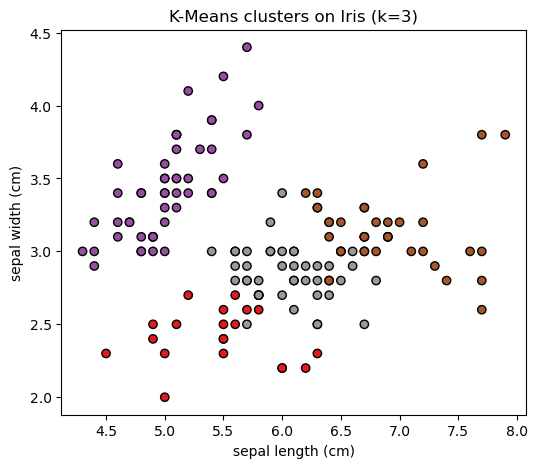

In [15]:

plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    df["sepal_length"],
    df["sepal_width"],
    c=df["cluster"],
    cmap=plt.cm.Set1,
    edgecolor="k"
)
plt.xlabel("sepal length (cm)")
plt.ylabel("sepal width (cm)")
plt.title("K-Means clusters on Iris (k=3)")
plt.show()


## Choose the number of clusters using the "Elbow Method"

C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

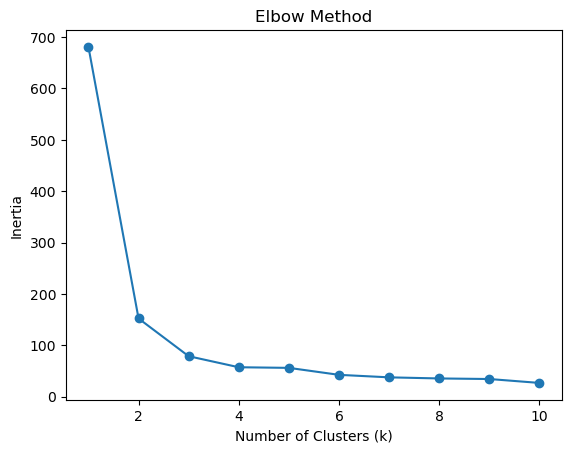

In [16]:
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=1)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

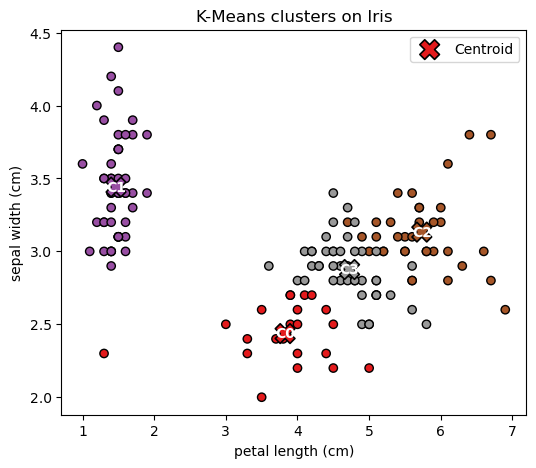

In [17]:
import numpy as np
 
# Compute centroids from the plotted features per cluster
centroids = (
    df.groupby("cluster")[["petal_length", "sepal_width"]]
      .mean()
      .sort_index()
      .to_numpy()  # shape: (n_clusters, 2)
)
 
plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    df["petal_length"],
    df["sepal_width"],
    c=df["cluster"],
    cmap=plt.cm.Set1,
    edgecolor="k"
)
 
# Use the same colormap and cluster indices for centroid coloring
plt.scatter(
    centroids[:, 0], centroids[:, 1],
    marker="X", s=200, c=np.arange(centroids.shape[0]),
    cmap=plt.cm.Set1, edgecolors="k", linewidths=1.2,
    label="Centroid"
)
 
# (Optional) label each centroid
for idx, (x, y) in enumerate(centroids):
    plt.text(x, y, f"C{idx}", fontsize=10, weight="bold",
             ha="center", va="center", color="white")
 
plt.xlabel("petal length (cm)")
plt.ylabel("sepal width (cm)")
plt.title("K-Means clusters on Iris")
plt.legend(loc="best")
plt.show()